<a href="https://colab.research.google.com/github/JB-GB/AI_for_Biomedical_Engineers/blob/main/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Artificial Intelligence**
## *Assignment 2: Processing Datasets in Python*
### Team:
#### Adrián Noriega Solís ID: 2111735
#### Aldo Reynold Alvarado Pérez ID: 2107251
#### Julieta Anahí Martínez Rangel ID: 2106210
#### Jorge Augusto Becerra Cifuentes ID: 2177839
#### Karla Ximena Rendón Calderón ID: 2044499

---
Class day & hour:
Tuesday at N4



##Libraries


- The first step is to import the libraries we will use throughout the activity; we use the "import" syntax for this, while also assigning abbreviations to the various libraries to streamline the process.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Data Loading and Exploration


### 1. Load the dataset using Pandas.

- For the first step, to load the dataset, we use the `df = pd.read` function to access the file previously uploaded to Google Colab, followed by the `print` operator to display the first few lines of the data.

In [2]:
# Source: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
# At least THAT WAS the source, but it doesn't exist anymore, this is the new link:
# https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset
# Load data from a CSV file
df = pd.read_csv('diabetes.csv')

### 2. Display the first few rows of the dataset.

- With the `df.head(10)` command, we can display the first ten rows of the dataset.

In [3]:
# Show the first 10 lines of data.
print(df.head(10))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   
5            5      116           74.0             27    102.5  25.6   
6            3       78           50.0             32     88.0  31.0   
7           10      115           70.0             27    102.5  35.3   
8            2      197           70.0             45    543.0  30.5   
9            8      125           96.0             32    169.5  34.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   2

### 3. Identify null or inconsistent values.

- Using the "null" filter displays a table of data meeting this criterion, allowing us to identify the specific data points that need modification.

In [4]:
# Check if there are null values (missing values) in any column and how to handle them.
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### 4. Generate descriptive statistics using .describe().

- The `df.describe()` command generates a table showing key dataset statistics, such as the mean, total count, minimums, maximums, etc.

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Part 2: Data Cleaning and Normalization
- In the second step, we modify the values identified earlier; as null values, they would otherwise impact future data processing.

### 1. Replace zero values in attribute columns with the median of each column.

- First, we identify columns containing biologically implausible values (specifically zeros) that should be changed, using `cols_change=[]`.

In [6]:
# We identify the colums we could change that make sense with implausible biological measures that are 0
cols_change = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for cols in cols_change:
  df[cols] = df[cols].replace(0, np.nan)
  df[cols] = df[cols].fillna(df[cols].median())


### 2. Normalize numerical data using Min-Max Scaling.

-  We then apply "MinMaxScaler" for normalization to ensure these values make sense.

In [7]:
#Now we call MinMaxScaler for normalize the numerical features
from sklearn.preprocessing import MinMaxScaler
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[features] = scaler.fit_transform(df[features])
df_normalized.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.186899,0.314928,0.234415,0.483333,1
1,0.058824,0.264516,0.428571,0.239130,0.106370,0.171779,0.116567,0.166667,0
2,0.470588,0.896774,0.408163,0.271739,0.186899,0.104294,0.253629,0.183333,1
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1


## Part 3: Data Visualization
- In the third step, having cleaned and normalized the data, we create more understandable visualizations using Matplotlib.

### 1. Histogram of glucose levels before and after normalization.

- First, we generate a histogram comparing values before and after normalization: `plt.hist(df["Glucose"]...)` displays the data prior to modification, whereas `plt.hist(df_normalized["Glucose"]...)` displays the new data, rendered using `plt.show()`.

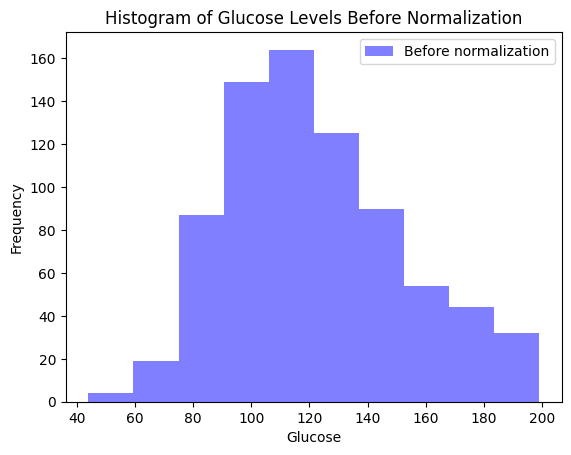

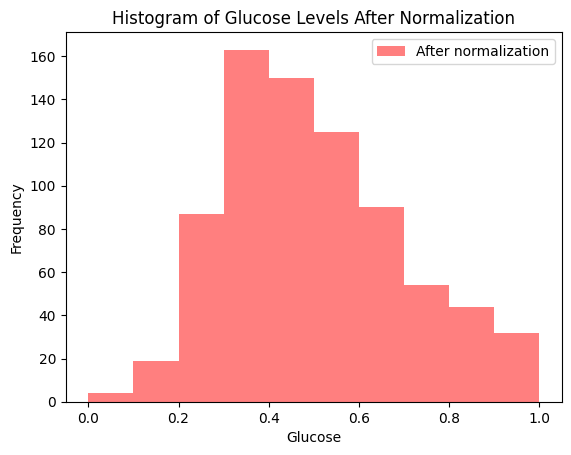

In [8]:
#Histogram before normalization
plt.hist(df['Glucose'], bins=10, alpha=0.5, color='blue', label='Before normalization')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Histogram of Glucose Levels Before Normalization')
plt.legend()
plt.show()
#Histogram after normalization
plt.hist(df_normalized['Glucose'], bins=10, alpha=0.5, color='red', label='After normalization')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Histogram of Glucose Levels After Normalization')
plt.legend()

### 2. Boxplot to identify outliers in blood presure

- To create a boxplot, we simply use `plt.boxplot(df['BloodPressure'])` with the variable we want to examine.

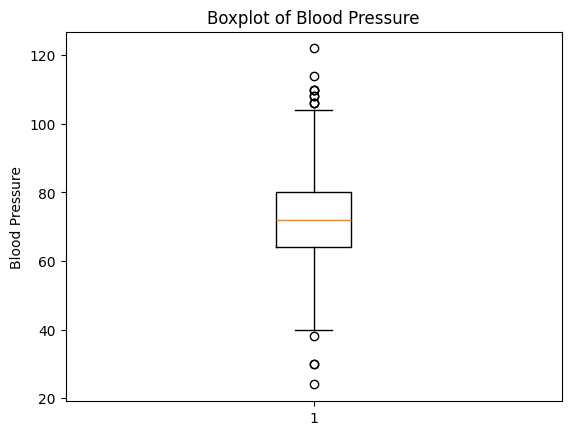

In [9]:
plt.boxplot(df['BloodPressure'])
plt.ylabel('Blood Pressure')
plt.title('Boxplot of Blood Pressure')
plt.show()

### 3. Scatter plot between Glucose and BMI to analyze correlation

- For a scatter plot, we use `plt.scatter(df["Glucose"], df["BMI"])` to plot both values, modifying to show points colored by  `c=df['Outcome']` based on the diabetes outcome (0 or 1)

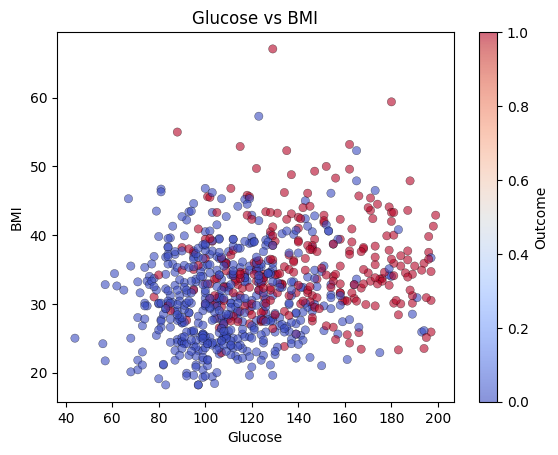

In [10]:
plt.scatter(df["Glucose"], df["BMI"], c=df['Outcome'], cmap='coolwarm', alpha=0.6, edgecolor="k", linewidth=0.3)
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.colorbar(label='Outcome') #based on the diabetes outcome (0 or 1)
plt.show()

### 4. Bar chart showing the number of patients with and without diabetes (Outcome).

- Finally, for the bar chart, we use `plt.bar(['No Diabetes', 'Diabetes'], df['Outcome'])` to compare the number of patients with and without diabetes.

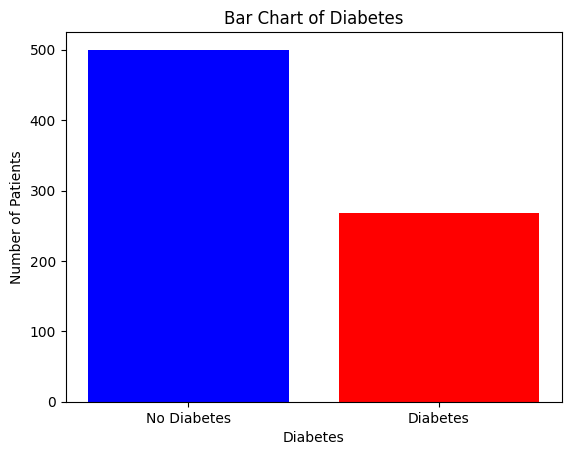

In [11]:
plt.bar(['No Diabetes', 'Diabetes'], df['Outcome'].value_counts(), color=['blue', 'red'])
plt.xlabel('Diabetes')
plt.ylabel('Number of Patients')
plt.title('Bar Chart of Diabetes')
plt.show()


- It is worth noting that, in addition to the functions already mentioned, we used chart modifiers such as `plt.xlabel()`, `plt.ylabel()`, and `plt.title()` to make the visualizations more presentable and easier to understand.

## Part 4: Answer The Following Questions

### 1. ***What impact do missing values have on data analysis?***

Missing values reduces the effective sample size, can bias estimates if the missingness is systematic, and may cause algorithms to fail or produce misleading patterns if not handled properly.

### 2. ***How can we detect and handle outliers in biomedical datasets?***

Outliers can be detected using descriptive statistics (extreme min/max), visual tools (boxplots, scatter plots), and statistical rules or many standard deviations from the mean.

### 3. ***What are some common causes of missing or incorrect data in biomedical studies?***

Common causes include measurement device failures, patients skipping tests, data entry errors, inconsistent protocols across sites, biological limits, and privacy-related redaction.

### 4. ***How does normalizing data improve the performance of Machine Learning models?***

Normalization puts features on comparable scales, which helps gradient-based algorithms converge faster and more stably, prevents features with large numeric ranges from dominating distance-based methods, and often improves generalization. Min-Max scaling maps features to a fixed range, making optimization landscapes better conditioned.

### 5. ***Why is visualizing data an important step before applying Machine Learning models?***

Visualization reveals distributions, class imbalance, potential outliers, and relationships, or lack thereof, between variables. It helps choose appropriate preprocessing, detect data quality issues, and form hypotheses about which features may be predictive, reducing the risk of building models on flawed assumptions.

### 6. ***Why is preprocessing critical when working with medical datasets?***

Medical data often contain measurement errors, physiologically impossible values (e.g., zero glucose), missingness, and strong class imbalance. Proper preprocessing ensures that models learn from realistic patterns rather than artifacts, which is essential for reliable, safe, and clinically meaningful predictions.

### 7. ***What ethical concerns should be considered when handling patient data?***

 Key concerns include privacy and confidentiality, informed consent for data use, potential bias and fairness (ensuring models do not disadvantage specific groups), transparency about limitations, and responsible deployment, avoiding over-reliance on automated decisions in clinical settings. Anonymization, secure storage, and audit trails are also critical.

###**Conclusion**
As this is our first actual programming assignment, we believe it serves as an excellent introduction to the Google Colab environment for coding and Kaggle for dataset acquisition. It also allows us to put into practice the libraries covered in class—specifically using pandas for data handling, and NumPy for mathematical functions that can be visualized with Matplotlib. Overall, we consider this a comprehensive activity; it provides the space to learn, experiment, and familiarize ourselves with the foundational concepts of artificial intelligence.

###**References**
Matthes, E. (2023). Python Crash Course. No Starch Press.

W3Schools Python Guide